# 02. LST + EGIS 통합 sample 생성

01이 만든 최종 EGIS cache를 읽어서 sample `.npz`를 생성한다. 01의 ready 파일과 392개 cache가 없으면 시작하지 않는다.

EGIS lookup은 실제 연도가 아니라 01 정책연도를 따른다.
- 2016-2018 → policy_year 2018
- 2024-2025 → policy_year 2024

condition은 `terrain + albedo + AWS + EGIS one-hot`이다. 기압, 대기질, NDVI는 쓰지 않는다.


In [32]:
# 필요하면 먼저 실행
%pip install -q numpy scipy pandas requests pyproj pillow tqdm matplotlib earthengine-api rasterio torch

from __future__ import annotations

from pathlib import Path
from io import BytesIO
from zipfile import ZipFile
import json
import math
import os
import time
import warnings
import getpass

import numpy as np
import pandas as pd
import requests
from pyproj import Transformer
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

warnings.filterwarnings("ignore")


Note: you may need to restart the kernel to use updated packages.


## 1. 설정과 EGIS preflight


In [20]:
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name in {"final", "attempt1", "attempt2", "attempt3"}:
    PROJECT_DIR = PROJECT_DIR.parent

ATTEMPT_DIR = PROJECT_DIR / "attempt3"
CANDIDATE_CSV = ATTEMPT_DIR / "lst_candidates.csv"
DATA_DIR = ATTEMPT_DIR / "lst_dataset"
SAMPLE_DIR = DATA_DIR / "samples"
RUN_DIR = DATA_DIR / "runs"
EGIS_CACHE_DIR = DATA_DIR / "egis_cache"
TERRAIN_REPAIR_CACHE_DIR = DATA_DIR / "repair_cache" / "terrain_srtm"
ALBEDO_REPAIR_CACHE_DIR = DATA_DIR / "repair_cache" / "albedo_attempt1"
AWS_FRAME_CACHE_DIR = DATA_DIR / "repair_cache" / "kma_aws_frames"
EGIS_READY_FILE = DATA_DIR / "egis_cache_ready.json"
EGIS_MISSING_FOR_02_CSV = DATA_DIR / "egis_cache_missing_for_02.csv"

GRID_N = 256
PIXEL_SIZE_M = 60
CRS_BASE = "EPSG:32653"
NODATA = -9999.0
LST_VALID_MIN_K = 150.0
LST_VALID_MAX_K = 380.0
HOUR_KST = "1100"

TERRAIN_BANDS = ["elevation", "slope", "aspect_sin", "aspect_cos", "hillshade_landsat"]
ALBEDO_BANDS = ["albedo"]
AWS_BANDS = ["avg_temp", "wind_u", "wind_v", "rain_1h", "humidity"]
TARGET_CHANNELS = ["lst_k_raw", "lst_k_filled"]
META_CHANNELS = ["day_sin", "day_cos", "sun_azimuth_norm", "sun_elevation_norm", "lat_norm", "lon_norm"]
HYBRID_CLASSES = [110, 120, 130, 140, 150, 160, 200, 300, 400, 500, 600, 710, 720]
HYBRID_CLASS_NAMES = {110: "urban_residential", 120: "urban_industrial", 130: "urban_commercial", 140: "urban_cultural_public", 150: "urban_transportation", 160: "urban_mixed", 200: "agriculture", 300: "forest", 400: "grassland", 500: "wetland", 600: "barren", 710: "water_inland", 720: "water_marine"}
EGIS_COLOR_MATCH_VERSION = "rgbtol_strict10_supersample4_marg8_announced_v1"
EGIS_MANUAL_NODATA_RULE_VERSION = "unknown_majority_8nbr_2022x4_v1"

for split in ["train", "val", "test"]:
    (SAMPLE_DIR / split).mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
TERRAIN_REPAIR_CACHE_DIR.mkdir(parents=True, exist_ok=True)
ALBEDO_REPAIR_CACHE_DIR.mkdir(parents=True, exist_ok=True)
AWS_FRAME_CACHE_DIR.mkdir(parents=True, exist_ok=True)

if not CANDIDATE_CSV.exists():
    raise FileNotFoundError(f"candidate csv missing: {CANDIDATE_CSV}. Run 00 first.")
if not EGIS_READY_FILE.exists():
    raise FileNotFoundError(f"EGIS ready file missing: {EGIS_READY_FILE}. Run 01 final cache build first.")

candidates = pd.read_csv(CANDIDATE_CSV)
candidates["date"] = pd.to_datetime(candidates["date"])
candidates["year"] = candidates["date"].dt.year
LAT_META_MEAN = float(candidates["latitude"].mean())
LAT_META_STD = float(candidates["latitude"].std(ddof=0)) if float(candidates["latitude"].std(ddof=0)) > 1e-6 else 1.0
LON_META_MEAN = float(candidates["longitude"].mean())
LON_META_STD = float(candidates["longitude"].std(ddof=0)) if float(candidates["longitude"].std(ddof=0)) > 1e-6 else 1.0
ready = json.loads(EGIS_READY_FILE.read_text(encoding="utf-8"))
if ready.get("color_match_version") != EGIS_COLOR_MATCH_VERSION or ready.get("manual_rule_version") != EGIS_MANUAL_NODATA_RULE_VERSION:
    raise RuntimeError(
        "EGIS ready file version mismatch. "
        f"ready color={ready.get('color_match_version')} manual={ready.get('manual_rule_version')}; "
        f"expected color={EGIS_COLOR_MATCH_VERSION} manual={EGIS_MANUAL_NODATA_RULE_VERSION}. "
        "Run 01 final cache build again."
    )
policy_table = pd.DataFrame(ready["egis_policy_table"])

def analysis_year_to_policy_year(year):
    year = int(year)
    hit = policy_table[(policy_table["analysis_year_min"] <= year) & (year <= policy_table["analysis_year_max"])]
    if hit.empty:
        raise ValueError(f"analysis year outside EGIS policy: {year}")
    return int(hit.iloc[0]["policy_year"])

def egis_cache_path(city, date_ymd):
    policy_year = analysis_year_to_policy_year(pd.Timestamp(date_ymd).year)
    safe_city = str(city).replace("/", "_")
    return EGIS_CACHE_DIR / f"egis_hybrid_lc_60m_{safe_city}_{policy_year}_epsg32653_{GRID_N}_{EGIS_COLOR_MATCH_VERSION}_{EGIS_MANUAL_NODATA_RULE_VERSION}.npz"

candidates["egis_policy_year"] = candidates["year"].map(analysis_year_to_policy_year)
expected = candidates[["city", "egis_policy_year"]].drop_duplicates().copy()
expected["cache"] = [egis_cache_path(r.city, f"{int(r.egis_policy_year)}-06-15") for r in expected.itertuples(index=False)]
expected["exists"] = expected["cache"].map(lambda p: p.exists())
missing = expected[~expected["exists"]].copy()
if not missing.empty:
    missing["cache"] = missing["cache"].map(str)
    missing.to_csv(EGIS_MISSING_FOR_02_CSV, index=False, encoding="utf-8-sig")
    raise FileNotFoundError(f"EGIS cache missing for 02: {len(missing)}. See {EGIS_MISSING_FOR_02_CSV}")

print("candidate rows:", len(candidates))
print("cities:", candidates["city"].nunique())
print("EGIS policy cache groups required:", len(expected))
print("ready cache expected:", ready.get("cache_files_expected"), "present:", ready.get("cache_files_present"))
print("split counts:", candidates["split"].value_counts().sort_index().to_dict() if "split" in candidates.columns else "no split")
print("meta channels:", META_CHANNELS)
print("lat/lon meta norm:", {"lat_mean": LAT_META_MEAN, "lat_std": LAT_META_STD, "lon_mean": LON_META_MEAN, "lon_std": LON_META_STD})


candidate rows: 3919
cities: 98
EGIS policy cache groups required: 686
ready cache expected: 686 present: 686
split counts: {'test': 482, 'train': 2834, 'val': 603}
meta channels: ['day_sin', 'day_cos', 'sun_azimuth_norm', 'sun_elevation_norm', 'lat_norm', 'lon_norm']
lat/lon meta norm: {'lat_mean': 36.22751454452666, 'lat_std': 0.974472059049708, 'lon_mean': 127.70786578208728, 'lon_std': 0.8830399708103981}


## 2. Earth Engine / KMA 초기화


In [ ]:
import ee

def validate_kma_auth_key(key):
    bad_tokens = ["°"]
    key = str(key).strip()
    if len(key) < 10 or any(tok in key for tok in bad_tokens):
        raise ValueError("KMA auth key looks invalid. Do not paste coordinates here.")
    return key

EE_PROJECT = os.environ.get("EE_PROJECT", "")
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)

KMA_AUTH_KEY = os.environ.get("KMA_AUTH_KEY") or getpass.getpass("KMA API authKey: ")
KMA_AUTH_KEY = validate_kma_auth_key(KMA_AUTH_KEY)
print("EE initialized; KMA key accepted")


EE initialized; KMA key accepted


## 3. grid와 EGIS one-hot


In [22]:
def make_patch_grid(center_lat, center_lon, grid_n=GRID_N, pixel_size_m=PIXEL_SIZE_M, crs_base=CRS_BASE):
    to_xy = Transformer.from_crs("EPSG:4326", crs_base, always_xy=True)
    cx, cy = to_xy.transform(float(center_lon), float(center_lat))
    half = grid_n * pixel_size_m / 2
    left, right = cx - half, cx + half
    bottom, top = cy - half, cy + half
    xs = left + (np.arange(grid_n) + 0.5) * pixel_size_m
    ys = top - (np.arange(grid_n) + 0.5) * pixel_size_m
    xx, yy = np.meshgrid(xs, ys)
    return {"n": grid_n, "pixel_size": pixel_size_m, "crs": crs_base, "left": left, "right": right, "bottom": bottom, "top": top, "xx": xx.astype(np.float32), "yy": yy.astype(np.float32)}

def egis_onehot_from_cache(path):
    with np.load(path, allow_pickle=True) as z:
        lc = z["egis_hybrid_lc_60m"].astype(np.int16)
        if (lc == 0).any():
            raise RuntimeError(f"EGIS cache still has unknown pixels: {path}")
        classes = z["hybrid_classes"].astype(int).tolist() if "hybrid_classes" in z.files else HYBRID_CLASSES
    arrays, names = [], []
    for cls in classes:
        label = HYBRID_CLASS_NAMES.get(int(cls), f"class_{cls}")
        arrays.append((lc == int(cls)).astype(np.float32)[None])
        names.append(f"egis_cat_{int(cls)}_{label}")
    return np.concatenate(arrays, axis=0), names

def valid_lst_mask(arr):
    arr = np.asarray(arr)
    return np.isfinite(arr) & (arr >= LST_VALID_MIN_K) & (arr <= LST_VALID_MAX_K)

def clean_lst_values(arr):
    arr = np.asarray(arr, dtype=np.float32).copy()
    arr[~valid_lst_mask(arr)] = np.nan
    return arr


## 4. EE download helper


In [23]:
import rasterio

def ee_region_for_grid(grid):
    return ee.Geometry.Rectangle([grid["left"], grid["bottom"], grid["right"], grid["top"]], proj=grid["crs"], geodesic=False)

def ee_stack(image, bands, grid):
    image = image.select(bands).toFloat().unmask(NODATA)
    transform = [grid["pixel_size"], 0, grid["left"], 0, -grid["pixel_size"], grid["top"]]
    params = {"name": "patch", "bands": bands, "crs": grid["crs"], "crs_transform": transform, "dimensions": [grid["n"], grid["n"]], "filePerBand": False, "format": "GEO_TIFF"}
    url = image.getDownloadURL(params)
    r = requests.get(url, timeout=300)
    r.raise_for_status()
    data = r.content
    if data.startswith(b"PK"):
        with ZipFile(BytesIO(data)) as zf:
            names = [n for n in zf.namelist() if n.lower().endswith((".tif", ".tiff"))]
            if not names:
                raise RuntimeError("EE zip has no tif")
            data = zf.read(names[0])
    with rasterio.open(BytesIO(data)) as ds:
        arr = ds.read(out_shape=(len(bands), grid["n"], grid["n"]), resampling=rasterio.enums.Resampling.nearest).astype(np.float32)
    arr[arr <= NODATA / 2] = np.nan
    return arr


## 5. Landsat terrain/albedo/LST


In [24]:
def landsat_image(row):
    scene_id = str(row.get("scene_id", ""))
    if scene_id and scene_id != "nan":
        return ee.Image(scene_id)
    return ee.ImageCollection(str(row["collection"])).filter(ee.Filter.eq("LANDSAT_PRODUCT_ID", str(row["landsat_product_id"]))).first()

def qa_clear_mask(img):
    qa = img.select("QA_PIXEL")
    return qa.bitwiseAnd(1 << 1).eq(0).And(qa.bitwiseAnd(1 << 2).eq(0)).And(qa.bitwiseAnd(1 << 3).eq(0)).And(qa.bitwiseAnd(1 << 4).eq(0)).And(qa.bitwiseAnd(1 << 5).eq(0))

def landsat_lst_image(row):
    img = landsat_image(row)
    lst = img.select("ST_B10").multiply(0.00341802).add(149.0).rename("lst_k_raw")
    clear = qa_clear_mask(img).And(img.select("ST_B10").gt(0)).rename("clear_mask")
    cloud = clear.Not().rename("cloud_fill_mask")
    return ee.Image.cat([lst.updateMask(clear), clear.toFloat(), cloud.toFloat()])

def terrain_image(row):
    # attempt1 기준 유지: NASADEM이 아니라 USGS SRTMGL1을 사용한다.
    dem = ee.Image("USGS/SRTMGL1_003").select("elevation").resample("bilinear")
    terrain = ee.Terrain.products(dem)
    slope = terrain.select("slope")
    aspect_rad = terrain.select("aspect").multiply(np.pi / 180.0)
    aspect_sin = aspect_rad.sin().rename("aspect_sin")
    aspect_cos = aspect_rad.cos().rename("aspect_cos")
    hillshade = ee.Terrain.hillshade(dem, float(row.get("sun_azimuth", 135.0)), float(row.get("sun_elevation", 45.0))).rename("hillshade_landsat")
    return ee.Image.cat([dem.rename("elevation"), slope.rename("slope"), aspect_sin, aspect_cos, hillshade])

def albedo_image(row):
    # attempt1 기준 유지: clear pixel 기반 albedo를 만들고 focal mean으로 구름/결측을 보완한다.
    img = landsat_image(row)
    clear_img = img.updateMask(qa_clear_mask(img))
    def sr(name):
        return clear_img.select(name).multiply(0.0000275).add(-0.2)
    albedo = sr("SR_B2").multiply(0.356).add(sr("SR_B4").multiply(0.130)).add(sr("SR_B5").multiply(0.373)).add(sr("SR_B6").multiply(0.085)).add(sr("SR_B7").multiply(0.072)).subtract(0.0018).rename("albedo")
    return albedo.unmask(albedo.focal_mean(radius=5, units="pixels", iterations=2)).rename("albedo")


## 6. AWS 11시 IDW 보간

기압은 쓰지 않는다.


In [25]:
import re

AWSH_BASE_URL = "https://apihub.kma.go.kr/api/typ01/url/awsh.php"
STN_BASE_URL = "https://apihub.kma.go.kr/api/typ01/url/stn_inf.php"
KMA_RETRIES = 5
KMA_BACKOFF_SECONDS = 3
AWSH_COLUMNS = {
    "TA": ["TM", "STN", "TA"],
    "WD": ["TM", "STN", "WD"],
    "WS": ["TM", "STN", "WS"],
    "RN": ["TM", "STN", "RN"],
    "HM": ["TM", "STN", "HM"],
}
AWS_VALUE_RENAME = {"TA": "avg_temp", "RN": "rain_1h", "HM": "humidity"}
_aws_frame_cache = {}
_aws_frame_last_source = None
_aws_cache_stats = {"memory": 0, "disk": 0, "api": 0}


def aws_frame_cache_path(tm):
    return AWS_FRAME_CACHE_DIR / f"kma_aws_{tm}.pkl"


def read_aws_frame_disk_cache(tm):
    path = aws_frame_cache_path(tm)
    if not path.exists():
        return None
    try:
        aws = pd.read_pickle(path)
        required = {"STN", "LON", "LAT", *AWS_BANDS}
        if not required.issubset(aws.columns):
            raise ValueError(f"cache columns missing: {sorted(required - set(aws.columns))}")
        return aws.copy()
    except Exception as exc:
        bad_path = path.with_suffix(path.suffix + ".bad")
        try:
            path.replace(bad_path)
        except Exception:
            pass
        print(f"[AWS disk cache ignored] {path.name}: {type(exc).__name__}: {exc}")
        return None


def write_aws_frame_disk_cache(tm, aws):
    path = aws_frame_cache_path(tm)
    tmp = path.with_suffix(path.suffix + ".tmp")
    aws.to_pickle(tmp)
    tmp.replace(path)


def decode_kma_response(content):
    for enc in ["utf-8", "cp949", "euc-kr"]:
        try:
            return content.decode(enc)
        except UnicodeDecodeError:
            continue
    return content.decode("utf-8", errors="replace")


def valid_data_lines(text):
    return [ln.strip() for ln in text.splitlines() if ln.strip() and not ln.startswith("#")]


def request_kma_with_retry(url, params, timeout=60):
    last_exc = None
    for attempt in range(1, KMA_RETRIES + 1):
        try:
            r = requests.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            return r
        except Exception as exc:
            last_exc = exc
            wait = KMA_BACKOFF_SECONDS * attempt
            print(f"[KMA retry {attempt}/{KMA_RETRIES}] {params} -> {type(exc).__name__}: {exc}; wait {wait}s")
            time.sleep(wait)
    raise RuntimeError(f"KMA request failed after retries: {params}; last={last_exc}")


def fetch_awsh_var(var, tm, auth_key):
    params = {"var": var, "tm": tm, "stn": "0", "help": "0", "authKey": auth_key}
    r = request_kma_with_retry(AWSH_BASE_URL, params, timeout=60)
    lines = valid_data_lines(decode_kma_response(r.content))
    rows = [re.split(r"\s+", ln)[: len(AWSH_COLUMNS[var])] for ln in lines]
    df = pd.DataFrame(rows, columns=AWSH_COLUMNS[var]) if rows else pd.DataFrame(columns=AWSH_COLUMNS[var])
    for col in df.columns:
        if col != "TM":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["STN"])
    df["STN"] = df["STN"].astype(int)
    return df


def fetch_station_info(auth_key, tm):
    params = {"inf": "AWS", "stn": "", "tm": tm, "help": "1", "authKey": auth_key}
    r = request_kma_with_retry(STN_BASE_URL, params, timeout=60)
    lines = valid_data_lines(decode_kma_response(r.content))
    rows = []
    for ln in lines:
        parts = re.split(r"\s+", ln)
        nums = [x for x in parts if re.fullmatch(r"-?\d+(\.\d+)?", x)]
        if len(nums) >= 3:
            rows.append({"STN": int(float(nums[0])), "LON": float(nums[1]), "LAT": float(nums[2])})
    df = pd.DataFrame(rows, columns=["STN", "LON", "LAT"])
    if df.empty:
        raise RuntimeError(f"KMA station info returned no AWS stations for tm={tm}")
    return df.drop_duplicates("STN")


def fetch_aws_frame(date_ymd, auth_key):
    global _aws_frame_last_source
    tm = pd.Timestamp(date_ymd).strftime("%Y%m%d") + HOUR_KST
    if tm in _aws_frame_cache:
        _aws_frame_last_source = f"MEM:{tm}"
        _aws_cache_stats["memory"] += 1
        return _aws_frame_cache[tm].copy()

    cached = read_aws_frame_disk_cache(tm)
    if cached is not None:
        _aws_frame_cache[tm] = cached.copy()
        _aws_frame_last_source = f"DISK:{tm}"
        _aws_cache_stats["disk"] += 1
        return cached.copy()

    aws = fetch_station_info(auth_key, tm)
    for var in AWSH_COLUMNS:
        df = fetch_awsh_var(var, tm, auth_key)
        aws = aws.merge(df[["STN", var]], on="STN", how="left")
    aws = aws.rename(columns=AWS_VALUE_RENAME)
    wd = np.deg2rad(aws["WD"].to_numpy(dtype=np.float32))
    ws = aws["WS"].to_numpy(dtype=np.float32)
    aws["wind_u"] = -ws * np.sin(wd)
    aws["wind_v"] = -ws * np.cos(wd)
    keep = ["STN", "LON", "LAT", "avg_temp", "wind_u", "wind_v", "rain_1h", "humidity"]
    aws = aws[keep].dropna(subset=["LON", "LAT"])
    if aws.empty:
        raise RuntimeError(f"KMA AWS frame has no station coordinates for {tm}")
    _aws_frame_cache[tm] = aws.copy()
    write_aws_frame_disk_cache(tm, aws)
    _aws_frame_last_source = f"API:{tm}"
    _aws_cache_stats["api"] += 1
    return aws.copy()


def idw_grid(points_xy, values, grid, power=2.0, k=12):
    pts = np.asarray(points_xy, dtype=np.float32)
    vals = np.asarray(values, dtype=np.float32)
    valid = np.isfinite(vals)
    pts, vals = pts[valid], vals[valid]
    if len(vals) == 0:
        return np.full((grid["n"], grid["n"]), np.nan, dtype=np.float32)
    out = np.empty((grid["n"], grid["n"]), dtype=np.float32)
    flat_x, flat_y, out_flat = grid["xx"].ravel(), grid["yy"].ravel(), out.ravel()
    for start in range(0, flat_x.size, 4096):
        end = min(start + 4096, flat_x.size)
        dx = flat_x[start:end, None] - pts[None, :, 0]
        dy = flat_y[start:end, None] - pts[None, :, 1]
        dist = np.sqrt(dx * dx + dy * dy)
        kk = min(k, dist.shape[1])
        idx = np.argpartition(dist, kk - 1, axis=1)[:, :kk]
        d = np.take_along_axis(dist, idx, axis=1)
        v = vals[idx]
        w = 1.0 / np.maximum(d, 1e-6) ** power
        pred = np.sum(w * v, axis=1) / np.sum(w, axis=1)
        exact = d < 1e-6
        if exact.any():
            rows = np.where(exact.any(axis=1))[0]
            for rr in rows:
                pred[rr] = v[rr, np.argmax(exact[rr])]
        out_flat[start:end] = pred.astype(np.float32)
    return out


def aws_patch(date_ymd, grid):
    aws = fetch_aws_frame(date_ymd, KMA_AUTH_KEY)
    to_xy = Transformer.from_crs("EPSG:4326", grid["crs"], always_xy=True)
    xs, ys = to_xy.transform(aws["LON"].to_numpy(), aws["LAT"].to_numpy())
    pts = np.column_stack([xs, ys])
    stacks = []
    for band in AWS_BANDS:
        stacks.append(idw_grid(pts, aws[band].to_numpy(dtype=np.float32), grid)[None])
    return np.concatenate(stacks, axis=0).astype(np.float32)


## 7. raw sample export


In [26]:

def safe_cache_token(value):
    return str(value).replace("/", "_").replace("\\", "_").replace(":", "_").replace(" ", "_")


def terrain_cache_path(row):
    city = safe_cache_token(row["city"])
    return TERRAIN_REPAIR_CACHE_DIR / f"terrain_srtm_static_{city}_epsg32653_{GRID_N}_{PIXEL_SIZE_M}m_v1.npz"


def albedo_cache_path_for_sample(path):
    return ALBEDO_REPAIR_CACHE_DIR / f"albedo_attempt1_{safe_cache_token(Path(path).stem)}.npz"


def local_hillshade_from_srtm_static(slope_deg, aspect_sin, aspect_cos, sun_azimuth, sun_elevation):
    slope = np.deg2rad(slope_deg.astype(np.float32))
    aspect = np.arctan2(aspect_sin.astype(np.float32), aspect_cos.astype(np.float32))
    az = np.deg2rad(float(sun_azimuth))
    zenith = np.deg2rad(90.0 - float(sun_elevation))
    shaded = np.cos(zenith) * np.cos(slope) + np.sin(zenith) * np.sin(slope) * np.cos(az - aspect)
    return np.clip(255.0 * shaded, 0.0, 255.0).astype(np.float32)


def load_or_build_srtm_static_terrain(row):
    cache = terrain_cache_path(row)
    if cache.exists():
        with np.load(cache, allow_pickle=True) as z:
            return z["terrain_static"].astype(np.float32), cache, "HIT"
    grid = make_patch_grid(float(row["latitude"]), float(row["longitude"]))
    dem = ee.Image("USGS/SRTMGL1_003").select("elevation").resample("bilinear")
    terrain = ee.Terrain.products(dem)
    slope = terrain.select("slope").rename("slope")
    aspect_rad = terrain.select("aspect").multiply(np.pi / 180.0)
    static_img = ee.Image.cat([
        dem.rename("elevation"),
        slope,
        aspect_rad.sin().rename("aspect_sin"),
        aspect_rad.cos().rename("aspect_cos"),
    ])
    static = ee_stack(static_img, ["elevation", "slope", "aspect_sin", "aspect_cos"], grid).astype(np.float32)
    np.savez_compressed(cache, terrain_static=static, bands=np.array(["elevation", "slope", "aspect_sin", "aspect_cos"]), city=np.array(str(row["city"])), latitude=np.array(float(row["latitude"]), dtype=np.float32), longitude=np.array(float(row["longitude"]), dtype=np.float32), source=np.array("USGS/SRTMGL1_003"))
    return static, cache, "MISS"


def terrain_from_cache(row):
    static, cache, cache_status = load_or_build_srtm_static_terrain(row)
    hillshade = local_hillshade_from_srtm_static(static[1], static[2], static[3], float(row.get("sun_azimuth", 135.0)), float(row.get("sun_elevation", 45.0)))
    return np.concatenate([static, hillshade[None]], axis=0).astype(np.float32), cache, cache_status


def albedo_from_cache(path, row):
    cache = albedo_cache_path_for_sample(path)
    if cache.exists():
        with np.load(cache, allow_pickle=True) as z:
            return z["albedo"].astype(np.float32), cache, "HIT"
    grid = make_patch_grid(float(row["latitude"]), float(row["longitude"]))
    albedo = ee_stack(albedo_image(row), ALBEDO_BANDS, grid).astype(np.float32)
    np.savez_compressed(cache, albedo=albedo, bands=np.array(ALBEDO_BANDS), city=np.array(str(row["city"])), date=np.array(pd.Timestamp(row["date"]).strftime("%Y-%m-%d")), landsat_product_id=np.array(str(row["landsat_product_id"])), source=np.array("attempt1_clear_mask_focal_mean"))
    return albedo, cache, "MISS"


def sample_path(row):
    split = str(row.get("split", "train"))
    city = str(row["city"])
    date = pd.Timestamp(row["date"]).strftime("%Y-%m-%d")
    product = str(row["landsat_product_id"])
    safe = f"{city}_{date}_{product}".replace("/", "_").replace(":", "_")
    return SAMPLE_DIR / split / f"{safe}.npz"

def sample_meta(row):
    doy = pd.Timestamp(row["date"]).dayofyear
    lat = float(row["latitude"])
    lon = float(row["longitude"])
    return np.array([
        math.sin(2 * math.pi * doy / 366.0),
        math.cos(2 * math.pi * doy / 366.0),
        float(row.get("sun_azimuth", 0.0)) / 360.0,
        float(row.get("sun_elevation", 45.0)) / 90.0,
        (lat - LAT_META_MEAN) / LAT_META_STD,
        (lon - LON_META_MEAN) / LON_META_STD,
    ], dtype=np.float32)

def export_sample(row, overwrite=False):
    out = sample_path(row)
    if out.exists() and not overwrite:
        return out, {"method": "skipped_existing"}
    grid = make_patch_grid(row["latitude"], row["longitude"])
    terrain, terrain_cache, terrain_cache_status = terrain_from_cache(row)
    albedo, albedo_cache, albedo_cache_status = albedo_from_cache(out, row)
    lst_stack = ee_stack(landsat_lst_image(row), ["lst_k_raw", "clear_mask", "cloud_fill_mask"], grid)
    aws = aws_patch(pd.Timestamp(row["date"]).strftime("%Y-%m-%d"), grid)
    egis_cache = egis_cache_path(row["city"], row["date"])
    egis_arr, egis_names = egis_onehot_from_cache(egis_cache)
    lst_raw = clean_lst_values(lst_stack[0])
    scene_valid_mask = valid_lst_mask(lst_raw)
    clear_mask = scene_valid_mask & (lst_stack[1] > 0.5)
    cloud_fill_mask = scene_valid_mask & ~clear_mask
    valid_scene_fraction = float(scene_valid_mask.mean())
    cloud_ratio = float(cloud_fill_mask.sum() / max(scene_valid_mask.sum(), 1))
    if valid_scene_fraction <= 0.05:
        return out, {"method": "skipped_scene_invalid", "cloud_ratio": cloud_ratio, "valid_scene_fraction": valid_scene_fraction}
    if cloud_ratio >= 0.80:
        return out, {"method": "skipped_cloud_high", "cloud_ratio": cloud_ratio, "valid_scene_fraction": valid_scene_fraction}
    condition = np.concatenate([terrain, albedo, aws, egis_arr], axis=0).astype(np.float32)
    target = np.stack([lst_raw, np.full_like(lst_raw, np.nan, dtype=np.float32)], axis=0).astype(np.float32)
    target_mask = np.stack([clear_mask, np.zeros_like(clear_mask)], axis=0).astype(np.uint8)
    out.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        out,
        condition=condition,
        condition_channels=np.array(TERRAIN_BANDS + ALBEDO_BANDS + AWS_BANDS + egis_names),
        target=target,
        target_channels=np.array(TARGET_CHANNELS),
        target_mask=target_mask,
        clear_mask=clear_mask[None].astype(np.uint8),
        cloud_fill_mask=cloud_fill_mask[None].astype(np.uint8),
        meta=sample_meta(row),
        meta_channels=np.array(META_CHANNELS),
        city=np.array(str(row["city"])),
        date=np.array(pd.Timestamp(row["date"]).strftime("%Y-%m-%d")),
        year=np.array(int(pd.Timestamp(row["date"]).year)),
        latitude=np.array(float(row["latitude"]), dtype=np.float32),
        longitude=np.array(float(row["longitude"]), dtype=np.float32),
        egis_policy_year=np.array(int(analysis_year_to_policy_year(pd.Timestamp(row["date"]).year))),
        landsat_product_id=np.array(str(row["landsat_product_id"])),
        scene_id=np.array(str(row.get("scene_id", ""))),
        split=np.array(str(row.get("split", "train"))),
        egis_cache_path=np.array(str(egis_cache.relative_to(DATA_DIR))),
        terrain_source=np.array("USGS/SRTMGL1_003_static_cache_local_hillshade"),
        terrain_cache_path=np.array(str(terrain_cache.relative_to(DATA_DIR))),
        terrain_cache_status=np.array(terrain_cache_status),
        albedo_source=np.array("attempt1_clear_mask_focal_mean"),
        albedo_cache_path=np.array(str(albedo_cache.relative_to(DATA_DIR))),
        albedo_cache_status=np.array(albedo_cache_status),
        condition_repair_version=np.array(CONDITION_REPAIR_VERSION if "CONDITION_REPAIR_VERSION" in globals() else "attempt1_srtm_albedo_v1"),
        target_repair_version=np.array(TARGET_REPAIR_VERSION if "TARGET_REPAIR_VERSION" in globals() else "attempt1_lst_clear_mask_v1"),
        cloud_ratio=np.array(cloud_ratio, dtype=np.float32),
        valid_scene_fraction=np.array(valid_scene_fraction, dtype=np.float32),
        meta_norm_info=np.array(json.dumps({"lat_mean": LAT_META_MEAN, "lat_std": LAT_META_STD, "lon_mean": LON_META_MEAN, "lon_std": LON_META_STD}, ensure_ascii=False)),
    )
    return out, {"method": "exported_raw", "cloud_ratio": cloud_ratio}

ONLY_SPLIT = None
LIMIT = None
OVERWRITE = False
STOP_ON_ERROR = False
SAVE_EVERY = 1
rows = candidates.copy()
if ONLY_SPLIT is not None:
    rows = rows[rows["split"] == ONLY_SPLIT]
if LIMIT is not None:
    rows = rows.head(LIMIT)
rows = rows.reset_index(drop=True)
print("export rows selected:", len(rows), "ONLY_SPLIT:", ONLY_SPLIT, "LIMIT:", LIMIT)


export rows selected: 3919 ONLY_SPLIT: None LIMIT: None


In [27]:
manifest_path = DATA_DIR / "manifest_raw.csv"
failure_path = DATA_DIR / "export_failures.csv"
RESUME_EXPORT = True
RESUME_STATUSES = {"OK", "SKIP_EXISTING", "SKIP_CLOUD", "SKIP_SCENE_INVALID"}

MANIFEST_COLUMNS = ["row_idx", "path", "split", "city", "date", "landsat_product_id", "status", "info"]
FAILURE_COLUMNS = ["row_idx", "split", "city", "date", "landsat_product_id", "error_type", "error", "traceback_tail"]


def read_csv_or_empty(path, columns):
    try:
        return pd.read_csv(path)
    except (pd.errors.EmptyDataError, FileNotFoundError):
        return pd.DataFrame(columns=columns)


def export_row_key(row):
    return (
        str(row.get("split")),
        str(row.get("city")),
        pd.Timestamp(row.get("date")).strftime("%Y-%m-%d"),
        str(row.get("landsat_product_id")),
    )


if RESUME_EXPORT and manifest_path.exists():
    prev_manifest = read_csv_or_empty(manifest_path, MANIFEST_COLUMNS)
    if prev_manifest.empty:
        manifest = []
    else:
        prev_manifest["date"] = pd.to_datetime(prev_manifest["date"]).dt.strftime("%Y-%m-%d")
        manifest = prev_manifest.to_dict(orient="records")
else:
    manifest = []

if RESUME_EXPORT and failure_path.exists():
    prev_failures = read_csv_or_empty(failure_path, FAILURE_COLUMNS)
    failures = prev_failures.to_dict(orient="records") if not prev_failures.empty else []
else:
    failures = []

completed = {}
for item in manifest:
    key = (str(item.get("split")), str(item.get("city")), str(item.get("date")), str(item.get("landsat_product_id")))
    status = str(item.get("status"))
    if status in RESUME_STATUSES:
        completed[key] = item

pd.DataFrame(manifest, columns=MANIFEST_COLUMNS).to_csv(manifest_path, index=False, encoding="utf-8-sig")
pd.DataFrame(failures, columns=FAILURE_COLUMNS).to_csv(failure_path, index=False, encoding="utf-8-sig")
print("resume manifest rows:", len(manifest), "completed rows:", len(completed), "failures:", len(failures))

for row_idx, row in tqdm(rows.iterrows(), total=len(rows), desc="export raw samples"):
    label = f"{row.get('split')} | {row.get('city')} | {pd.Timestamp(row.get('date')).strftime('%Y-%m-%d')} | {row.get('landsat_product_id')}"
    key = export_row_key(row)
    if key in completed and not OVERWRITE:
        prev = completed[key]
        status = str(prev.get("status"))
        print(f"[RESUME_{status} {len(manifest):04d}/{len(rows)}] {label} AWS=RESUME stats={globals().get('_aws_cache_stats', {})}")
        continue
    try:
        out, info = export_sample(row, overwrite=OVERWRITE)
        method = info.get("method")
        if method == "skipped_existing":
            status = "SKIP_EXISTING"
        elif method == "skipped_cloud_high":
            status = "SKIP_CLOUD"
        elif method == "skipped_scene_invalid":
            status = "SKIP_SCENE_INVALID"
        else:
            status = "OK"
        path_value = out.relative_to(DATA_DIR).as_posix() if out.exists() else ""
        item = {"row_idx": int(row_idx), "path": path_value, "split": row.get("split"), "city": row.get("city"), "date": pd.Timestamp(row.get("date")).strftime("%Y-%m-%d"), "landsat_product_id": row.get("landsat_product_id"), "status": status, "info": json.dumps(info, ensure_ascii=False)}
        manifest.append(item)
        completed[key] = item
        suffix = f" -> {out.name}" if out.exists() else f" cloud_ratio={info.get('cloud_ratio', float('nan')):.3f}"
        aws_note = f" AWS={globals().get('_aws_frame_last_source', None)} stats={globals().get('_aws_cache_stats', {})}"
        print(f"[{status} {len(manifest):04d}/{len(rows)}] {label}{suffix}{aws_note}")
    except Exception as exc:
        import traceback
        tb = traceback.format_exc()
        failures.append({"row_idx": int(row_idx), "split": row.get("split"), "city": row.get("city"), "date": str(row.get("date")), "landsat_product_id": row.get("landsat_product_id"), "error_type": type(exc).__name__, "error": repr(exc), "traceback_tail": tb[-3000:]})
        print("\n" + "=" * 100)
        print(f"[FAIL {len(failures):04d}/{len(rows)}] {label}")
        print(f"{type(exc).__name__}: {exc}")
        print(tb[-2000:])
        print("=" * 100 + "\n")
        if STOP_ON_ERROR:
            pd.DataFrame(manifest, columns=MANIFEST_COLUMNS).to_csv(manifest_path, index=False, encoding="utf-8-sig")
            pd.DataFrame(failures, columns=FAILURE_COLUMNS).to_csv(failure_path, index=False, encoding="utf-8-sig")
            raise
    if (len(manifest) + len(failures)) % SAVE_EVERY == 0:
        pd.DataFrame(manifest, columns=MANIFEST_COLUMNS).drop_duplicates(["split", "city", "date", "landsat_product_id"], keep="last").to_csv(manifest_path, index=False, encoding="utf-8-sig")
        pd.DataFrame(failures, columns=FAILURE_COLUMNS).to_csv(failure_path, index=False, encoding="utf-8-sig")

manifest_df = pd.DataFrame(manifest, columns=MANIFEST_COLUMNS).drop_duplicates(["split", "city", "date", "landsat_product_id"], keep="last")
failure_df = pd.DataFrame(failures, columns=FAILURE_COLUMNS)
manifest_df.to_csv(manifest_path, index=False, encoding="utf-8-sig")
failure_df.to_csv(failure_path, index=False, encoding="utf-8-sig")
status_counts = manifest_df["status"].value_counts().to_dict() if not manifest_df.empty else {}
print("raw export done. manifest:", len(manifest_df), "fail:", len(failure_df), "status_counts:", status_counts)
print("AWS cache stats:", globals().get("_aws_cache_stats", {}), "memory_dates:", len(globals().get("_aws_frame_cache", {})), "disk_dates:", len(list(AWS_FRAME_CACHE_DIR.glob("kma_aws_*.pkl"))))
print("manifest:", manifest_path)
print("failures:", failure_path)


resume manifest rows: 662 completed rows: 662 failures: 0


export raw samples:   0%|          | 0/3919 [00:00<?, ?it/s]

[RESUME_OK 0662/3919] test | andong | 2016-03-02 | LC08_L2SP_114035_20160302_20200907_02_T1 AWS=RESUME stats={'memory': 0, 'disk': 0, 'api': 0}
[RESUME_OK 0662/3919] test | andong | 2016-08-09 | LC08_L2SP_114035_20160809_20200906_02_T1 AWS=RESUME stats={'memory': 0, 'disk': 0, 'api': 0}
[RESUME_OK 0662/3919] test | andong | 2017-06-25 | LC08_L2SP_114035_20170625_20200903_02_T1 AWS=RESUME stats={'memory': 0, 'disk': 0, 'api': 0}
[RESUME_OK 0662/3919] test | andong | 2018-02-04 | LC08_L2SP_114035_20180204_20200902_02_T1 AWS=RESUME stats={'memory': 0, 'disk': 0, 'api': 0}
[RESUME_OK 0662/3919] test | andong | 2018-10-02 | LC08_L2SP_114035_20181002_20200830_02_T1 AWS=RESUME stats={'memory': 0, 'disk': 0, 'api': 0}
[RESUME_OK 0662/3919] test | andong | 2022-07-25 | LC08_L2SP_114035_20220725_20220802_02_T1 AWS=RESUME stats={'memory': 0, 'disk': 0, 'api': 0}
[RESUME_OK 0662/3919] test | andong | 2023-03-30 | LC09_L2SP_114035_20230330_20230401_02_T1 AWS=RESUME stats={'memory': 0, 'disk': 0, 'a

In [28]:
manifest_df = read_csv_or_empty(DATA_DIR / "manifest_raw.csv", MANIFEST_COLUMNS) if "read_csv_or_empty" in globals() else pd.read_csv(DATA_DIR / "manifest_raw.csv")
status_counts = manifest_df["status"].value_counts().to_dict()
cloud_skip_count = int((manifest_df["status"] == "SKIP_CLOUD").sum())
scene_invalid_count = int((manifest_df["status"] == "SKIP_SCENE_INVALID").sum())
usable_count = int(manifest_df["status"].isin(["OK", "SKIP_EXISTING"]).sum())
print("manifest status counts:", status_counts)
print("usable for DNN/training/validation:", usable_count)
print("excluded due to cloud >= 80%:", cloud_skip_count)
print("excluded due to invalid Landsat scene coverage:", scene_invalid_count)
if (manifest_df.loc[manifest_df["status"].isin(["SKIP_CLOUD", "SKIP_SCENE_INVALID"]), "path"].fillna("").astype(str) != "").any():
    raise RuntimeError("Skipped rows unexpectedly have sample paths; do not use them for training/validation.")


manifest status counts: {'OK': 3631, 'SKIP_SCENE_INVALID': 286}
usable for DNN/training/validation: 3631
excluded due to cloud >= 80%: 0
excluded due to invalid Landsat scene coverage: 286


## 8. raw NPZ 복구/QC

> raw export에서 이미 SRTM terrain, clear 기반 albedo, EGIS, AWS가 들어갔는지 검증하고, target/mask 일관성을 정리한 뒤
> HEALTHY 샘플만 DNN/CVAE로 넘기는 QC 단계.


In [29]:

CONDITION_REPAIR_VERSION = "attempt1_srtm_albedo_v1"
TARGET_REPAIR_VERSION = "attempt1_lst_clear_mask_v1"
REPAIR_OVERWRITE_CONDITION = False
REPAIR_LIMIT = None
MIN_CLEAR_PIXELS_FOR_DNN = 1
DNN_REQUIRED_FEATURE_NAMES = TERRAIN_BANDS + ALBEDO_BANDS + AWS_BANDS

manifest_path = DATA_DIR / "manifest_raw.csv"
if not manifest_path.exists():
    raise FileNotFoundError("manifest_raw.csv missing. Run raw export first.")
manifest_df = read_csv_or_empty(manifest_path, MANIFEST_COLUMNS) if "read_csv_or_empty" in globals() else pd.read_csv(manifest_path)
allowed_status = {"OK", "SKIP_EXISTING"}
raw_sample_paths = [DATA_DIR / p for p in manifest_df.loc[manifest_df["status"].isin(allowed_status) & manifest_df["path"].notna() & (manifest_df["path"].astype(str) != ""), "path"].astype(str)]
raw_sample_paths = sorted([p for p in raw_sample_paths if p.exists()])
if REPAIR_LIMIT is not None:
    raw_sample_paths = raw_sample_paths[:REPAIR_LIMIT]
print("raw samples for repair/QC:", len(raw_sample_paths))

candidate_lookup_for_repair = candidates.copy()
candidate_lookup_for_repair["date_key"] = pd.to_datetime(candidate_lookup_for_repair["date"]).dt.strftime("%Y-%m-%d")


def scalar_str(value):
    try:
        return str(value.item())
    except Exception:
        return str(value)


def as_2d_mask(arr):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr[0].astype(bool)
    return arr.astype(bool)


def row_for_sample(path):
    with np.load(path, allow_pickle=True) as z:
        city = scalar_str(z["city"])
        date = scalar_str(z["date"])
        product = scalar_str(z["landsat_product_id"])
        split = scalar_str(z["split"]) if "split" in z.files else None
    hit = candidate_lookup_for_repair[
        (candidate_lookup_for_repair["city"].astype(str) == city)
        & (candidate_lookup_for_repair["date_key"].astype(str) == date)
        & (candidate_lookup_for_repair["landsat_product_id"].astype(str) == product)
    ]
    if split is not None and "split" in hit.columns:
        hit_split = hit[hit["split"].astype(str) == split]
        if not hit_split.empty:
            hit = hit_split
    if hit.empty:
        raise KeyError(f"candidate row not found: {path.name} | {city} {date} {product}")
    return hit.iloc[0]



def safe_cache_token(value):
    return str(value).replace("/", "_").replace("\\", "_").replace(":", "_").replace(" ", "_")


def terrain_cache_path(row):
    city = safe_cache_token(row["city"])
    return TERRAIN_REPAIR_CACHE_DIR / f"terrain_srtm_static_{city}_epsg32653_{GRID_N}_{PIXEL_SIZE_M}m_v1.npz"


def albedo_cache_path(path):
    return ALBEDO_REPAIR_CACHE_DIR / f"albedo_attempt1_{safe_cache_token(Path(path).stem)}.npz"


def local_hillshade_from_srtm_static(slope_deg, aspect_sin, aspect_cos, sun_azimuth, sun_elevation):
    # EE Terrain.hillshade와 같은 의미의 태양각 기반 조명값을 SRTM slope/aspect에서 로컬 계산한다.
    slope = np.deg2rad(slope_deg.astype(np.float32))
    aspect = np.arctan2(aspect_sin.astype(np.float32), aspect_cos.astype(np.float32))
    az = np.deg2rad(float(sun_azimuth))
    zenith = np.deg2rad(90.0 - float(sun_elevation))
    shaded = np.cos(zenith) * np.cos(slope) + np.sin(zenith) * np.sin(slope) * np.cos(az - aspect)
    return np.clip(255.0 * shaded, 0.0, 255.0).astype(np.float32)


def load_or_build_srtm_static_terrain(row):
    cache = terrain_cache_path(row)
    if cache.exists():
        with np.load(cache, allow_pickle=True) as z:
            return z["terrain_static"].astype(np.float32), cache, "HIT"
    grid = make_patch_grid(float(row["latitude"]), float(row["longitude"]))
    dem = ee.Image("USGS/SRTMGL1_003").select("elevation").resample("bilinear")
    terrain = ee.Terrain.products(dem)
    slope = terrain.select("slope").rename("slope")
    aspect_rad = terrain.select("aspect").multiply(np.pi / 180.0)
    static_img = ee.Image.cat([
        dem.rename("elevation"),
        slope,
        aspect_rad.sin().rename("aspect_sin"),
        aspect_rad.cos().rename("aspect_cos"),
    ])
    static = ee_stack(static_img, ["elevation", "slope", "aspect_sin", "aspect_cos"], grid).astype(np.float32)
    np.savez_compressed(
        cache,
        terrain_static=static,
        bands=np.array(["elevation", "slope", "aspect_sin", "aspect_cos"]),
        city=np.array(str(row["city"])),
        latitude=np.array(float(row["latitude"]), dtype=np.float32),
        longitude=np.array(float(row["longitude"]), dtype=np.float32),
        source=np.array("USGS/SRTMGL1_003"),
    )
    return static, cache, "MISS"


def terrain_from_cache(row):
    static, cache, cache_status = load_or_build_srtm_static_terrain(row)
    hillshade = local_hillshade_from_srtm_static(
        static[1],
        static[2],
        static[3],
        float(row.get("sun_azimuth", 135.0)),
        float(row.get("sun_elevation", 45.0)),
    )
    terrain = np.concatenate([static, hillshade[None]], axis=0).astype(np.float32)
    return terrain, cache, cache_status


def albedo_from_cache(path, row):
    cache = albedo_cache_path(path)
    if cache.exists():
        with np.load(cache, allow_pickle=True) as z:
            return z["albedo"].astype(np.float32), cache, "HIT"
    grid = make_patch_grid(float(row["latitude"]), float(row["longitude"]))
    albedo = ee_stack(albedo_image(row), ALBEDO_BANDS, grid).astype(np.float32)
    np.savez_compressed(
        cache,
        albedo=albedo,
        bands=np.array(ALBEDO_BANDS),
        city=np.array(str(row["city"])),
        date=np.array(pd.Timestamp(row["date"]).strftime("%Y-%m-%d")),
        landsat_product_id=np.array(str(row["landsat_product_id"])),
        source=np.array("attempt1_clear_mask_focal_mean"),
    )
    return albedo, cache, "MISS"


def replace_condition_attempt1(path):
    with np.load(path, allow_pickle=True) as z:
        data = {k: z[k] for k in z.files}
    old_version = scalar_str(data.get("condition_repair_version", np.array(""))) if "condition_repair_version" in data else ""
    if old_version == CONDITION_REPAIR_VERSION and not REPAIR_OVERWRITE_CONDITION:
        return data, "SKIP_CONDITION_EXISTS"
    channels = [str(x) for x in data["condition_channels"]]
    missing = [ch for ch in DNN_REQUIRED_FEATURE_NAMES if ch not in channels]
    if missing:
        raise KeyError(f"missing condition channels before repair: {missing}")
    row = row_for_sample(path)
    terrain, terrain_cache, terrain_cache_status = terrain_from_cache(row)
    albedo, albedo_cache, albedo_cache_status = albedo_from_cache(path, row)
    condition = data["condition"].astype(np.float32)
    for offset, ch in enumerate(TERRAIN_BANDS):
        condition[channels.index(ch)] = terrain[offset]
    for offset, ch in enumerate(ALBEDO_BANDS):
        condition[channels.index(ch)] = albedo[offset]
    data["condition"] = condition
    data["condition_repair_version"] = np.array(CONDITION_REPAIR_VERSION)
    data["terrain_source"] = np.array("USGS/SRTMGL1_003_static_cache_local_hillshade")
    data["terrain_cache_path"] = np.array(str(terrain_cache.relative_to(DATA_DIR)))
    data["terrain_cache_status"] = np.array(terrain_cache_status)
    data["albedo_source"] = np.array("attempt1_clear_mask_focal_mean")
    data["albedo_cache_path"] = np.array(str(albedo_cache.relative_to(DATA_DIR)))
    data["albedo_cache_status"] = np.array(albedo_cache_status)
    return data, f"OK_CONDITION_REPAIRED_terrain_{terrain_cache_status}_albedo_{albedo_cache_status}"


def update_sample_metadata(data, row):
    data["meta"] = sample_meta(row)
    data["meta_channels"] = np.array(META_CHANNELS)
    data["latitude"] = np.array(float(row["latitude"]), dtype=np.float32)
    data["longitude"] = np.array(float(row["longitude"]), dtype=np.float32)
    data["meta_norm_info"] = np.array(json.dumps({"lat_mean": LAT_META_MEAN, "lat_std": LAT_META_STD, "lon_mean": LON_META_MEAN, "lon_std": LON_META_STD}, ensure_ascii=False))
    return data


def normalize_target_attempt1(data):
    target = data["target"].astype(np.float32)
    if "lst_clear" in data:
        lst_clear = clean_lst_values(data["lst_clear"].astype(np.float32))
    else:
        lst_clear = clean_lst_values(target[0])
    clear_mask = valid_lst_mask(lst_clear)
    lst_clear[~clear_mask] = np.nan
    missing_mask = ~np.isfinite(lst_clear)

    out_target = np.full((2, GRID_N, GRID_N), np.nan, dtype=np.float32)
    out_target[0] = lst_clear
    target_mask = np.zeros((2, GRID_N, GRID_N), dtype=np.uint8)
    target_mask[0] = clear_mask.astype(np.uint8)

    data["target"] = out_target
    data["target_channels"] = np.array(["lst_k_raw", "lst_k_filled"])
    data["target_mask"] = target_mask
    data["lst_clear"] = lst_clear.astype(np.float32)
    data["clear_mask"] = clear_mask[None].astype(np.uint8)
    data["cloud_fill_mask"] = missing_mask[None].astype(np.uint8)
    data["target_repair_version"] = np.array(TARGET_REPAIR_VERSION)
    return data


def quality_row(path, data, condition_status):
    channels = [str(x) for x in data["condition_channels"]]
    condition = data["condition"].astype(np.float32)
    lst_clear = data["lst_clear"].astype(np.float32)
    clear_mask = as_2d_mask(data["clear_mask"])
    target = data["target"].astype(np.float32)
    target_mask = data["target_mask"].astype(np.uint8)
    missing_channels = [ch for ch in DNN_REQUIRED_FEATURE_NAMES if ch not in channels]
    all_nan_features = []
    feature_nan_ratios = {}
    for ch in DNN_REQUIRED_FEATURE_NAMES:
        if ch in channels:
            arr = condition[channels.index(ch)]
            finite = np.isfinite(arr)
            feature_nan_ratios[ch] = float((~finite).mean())
            if not finite.any():
                all_nan_features.append(ch)
    bad_valid_target = int(((target_mask[0].astype(bool)) & ~valid_lst_mask(target[0])).sum())
    clear_pixels = int(clear_mask.sum())
    if missing_channels:
        qc_status = "BROKEN_MISSING_CONDITION_CHANNEL"
    elif all_nan_features:
        qc_status = "BROKEN_ALL_NAN_CONDITION_FEATURE"
    elif bad_valid_target:
        qc_status = "BROKEN_BAD_LST_MARKED_VALID"
    elif clear_pixels < MIN_CLEAR_PIXELS_FOR_DNN:
        qc_status = "EXCLUDE_NO_CLEAR_LST"
    else:
        qc_status = "HEALTHY"
    return {
        "file": path.relative_to(DATA_DIR).as_posix(),
        "qc_status": qc_status,
        "condition_status": condition_status,
        "clear_pixels": clear_pixels,
        "clear_fraction": float(clear_mask.mean()),
        "missing_pixels_for_fill": int((~np.isfinite(lst_clear)).sum()),
        "raw_invalid_finite_pixels": int((np.isfinite(target[0]) & ~valid_lst_mask(target[0])).sum()),
        "bad_valid_target_pixels": bad_valid_target,
        "missing_condition_channels": ";".join(missing_channels),
        "all_nan_condition_features": ";".join(all_nan_features),
        "max_feature_nan_ratio": max(feature_nan_ratios.values()) if feature_nan_ratios else np.nan,
    }

repair_rows = []
for path in tqdm(raw_sample_paths, desc="repair/QC raw npz"):
    try:
        data, condition_status = replace_condition_attempt1(path)
        sample_row = row_for_sample(path)
        data = update_sample_metadata(data, sample_row)
        data = normalize_target_attempt1(data)
        row = quality_row(path, data, condition_status)
        tmp = path.with_suffix(path.suffix + ".tmp")
        np.savez_compressed(tmp, **data)
        tmp_npz = Path(str(tmp) + ".npz") if not str(tmp).endswith(".npz") else tmp
        tmp_npz.replace(path)
        repair_rows.append(row)
        print(f"[{row['qc_status']}] {path.name} clear={row['clear_fraction']:.3f} missing={row['missing_pixels_for_fill']}")
    except Exception as exc:
        repair_rows.append({"file": path.relative_to(DATA_DIR).as_posix(), "qc_status": "REPAIR_FAIL", "condition_status": "FAIL", "error": repr(exc)})
        pd.DataFrame(repair_rows).to_csv(DATA_DIR / "raw_repair_quality_report.csv", index=False, encoding="utf-8-sig")
        print(f"[REPAIR FAIL] {path.name}: {type(exc).__name__}: {exc}")
        raise

repair_df = pd.DataFrame(repair_rows)
repair_df.to_csv(DATA_DIR / "raw_repair_quality_report.csv", index=False, encoding="utf-8-sig")
dnn_sample_paths = [DATA_DIR / p for p in repair_df.loc[repair_df["qc_status"].eq("HEALTHY"), "file"].astype(str)]
print("QC counts:", repair_df["qc_status"].value_counts().to_dict() if not repair_df.empty else {})
print("DNN usable samples:", len(dnn_sample_paths), "/", len(repair_df))
repair_df.head()


raw samples for repair/QC: 3631


repair/QC raw npz:   0%|          | 0/3631 [00:00<?, ?it/s]

[HEALTHY] andong_2016-03-02_LC08_L2SP_114035_20160302_20200907_02_T1.npz clear=0.943 missing=3728
[HEALTHY] andong_2016-08-09_LC08_L2SP_114035_20160809_20200906_02_T1.npz clear=0.588 missing=26980
[HEALTHY] andong_2017-06-25_LC08_L2SP_114035_20170625_20200903_02_T1.npz clear=0.310 missing=45242
[HEALTHY] andong_2018-02-04_LC08_L2SP_114035_20180204_20200902_02_T1.npz clear=0.920 missing=5262
[HEALTHY] andong_2018-10-02_LC08_L2SP_114035_20181002_20200830_02_T1.npz clear=0.836 missing=10726
[HEALTHY] andong_2022-07-25_LC08_L2SP_114035_20220725_20220802_02_T1.npz clear=0.599 missing=26291
[HEALTHY] andong_2023-03-30_LC09_L2SP_114035_20230330_20230401_02_T1.npz clear=0.340 missing=43247
[HEALTHY] andong_2024-01-04_LC08_L2SP_114035_20240104_20240114_02_T1.npz clear=0.929 missing=4663
[HEALTHY] andong_2024-06-04_LC09_L2SP_114035_20240604_20240605_02_T1.npz clear=0.881 missing=7776
[HEALTHY] andong_2025-09-27_LC09_L2SP_114035_20250927_20250928_02_T1.npz clear=0.867 missing=8686
[HEALTHY] ansan

,file,qc_status,condition_status,clear_pixels,clear_fraction,missing_pixels_for_fill,raw_invalid_finite_pixels,bad_valid_target_pixels,missing_condition_channels,all_nan_condition_features,max_feature_nan_ratio
0,samples/test/andong_2016-03-02_LC08_L2SP_11403...,HEALTHY,SKIP_CONDITION_EXISTS,61808,0.943115,3728,0,0,,,0.000000
1,samples/test/andong_2016-08-09_LC08_L2SP_11403...,HEALTHY,SKIP_CONDITION_EXISTS,38556,0.588318,26980,0,0,,,0.215561
2,samples/test/andong_2017-06-25_LC08_L2SP_11403...,HEALTHY,SKIP_CONDITION_EXISTS,20294,0.309662,45242,0,0,,,0.335159
3,samples/test/andong_2018-02-04_LC08_L2SP_11403...,HEALTHY,SKIP_CONDITION_EXISTS,60274,0.919708,5262,0,0,,,0.000000
4,samples/test/andong_2018-10-02_LC08_L2SP_11403...,HEALTHY,SKIP_CONDITION_EXISTS,54810,0.836334,10726,0,0,,,0.000000


## 9. global DNN LST 보간




In [33]:

import torch
import torch.nn as nn

CLOUD_FILL_RUN_DIR = RUN_DIR / "cloud_fill_dnn"
CLOUD_FILL_RUN_DIR.mkdir(parents=True, exist_ok=True)
CLOUD_FILL_CHECKPOINT = CLOUD_FILL_RUN_DIR / "cloud_fill_dnn_global.pt"
CLOUD_FILL_FEATURE_NAMES = [
    "elevation",
    "slope",
    "aspect_sin",
    "aspect_cos",
    "hillshade_landsat",
    "albedo",
    "avg_temp",
    "wind_u",
    "wind_v",
    "rain_1h",
    "humidity",
]
CLOUD_FILL_META_FEATURE_NAMES = META_CHANNELS.copy()
TRAIN_PIXELS_PER_SAMPLE = 2500
CLOUD_FILL_EPOCHS = 80
CLOUD_FILL_BATCH_SIZE = 8192
CLOUD_FILL_LR = 2e-3
CLOUD_FILL_PATIENCE = 10
CLOUD_FILL_SEED = 42

if "dnn_sample_paths" not in globals():
    repair_report = DATA_DIR / "raw_repair_quality_report.csv"
    if not repair_report.exists():
        raise FileNotFoundError("raw_repair_quality_report.csv missing. Run raw NPZ repair/QC first.")
    repair_df = pd.read_csv(repair_report)
    dnn_sample_paths = [DATA_DIR / p for p in repair_df.loc[repair_df["qc_status"].eq("HEALTHY"), "file"].astype(str)]
    dnn_sample_paths = sorted([p for p in dnn_sample_paths if p.exists()])
print("DNN samples:", len(dnn_sample_paths), "checkpoint:", CLOUD_FILL_CHECKPOINT)
if not dnn_sample_paths:
    raise RuntimeError("No HEALTHY samples for DNN cloud fill.")

class LSTFillMLP(nn.Module):
    def __init__(self, in_dim, width=96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, width),
            nn.SiLU(),
            nn.BatchNorm1d(width),
            nn.Linear(width, width),
            nn.SiLU(),
            nn.BatchNorm1d(width),
            nn.Linear(width, width // 2),
            nn.SiLU(),
            nn.Linear(width // 2, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


def fill_nan_nearest_2d(arr):
    arr = arr.astype(np.float32, copy=True)
    mask = np.isfinite(arr)
    if mask.all():
        return arr
    if not mask.any():
        return np.zeros_like(arr, dtype=np.float32)
    idx = distance_transform_edt(~mask, return_distances=False, return_indices=True)
    return arr[tuple(idx)].astype(np.float32)


def fill_nan_nearest_chw(chw):
    return np.stack([fill_nan_nearest_2d(chw[i]) for i in range(chw.shape[0])], axis=0)


def standardize_features(x, mean=None, std=None):
    if mean is None:
        mean = np.nanmean(x, axis=0, keepdims=True)
    if std is None:
        std = np.nanstd(x, axis=0, keepdims=True)
    std = np.where(std < 1e-6, 1.0, std)
    return ((x - mean) / std).astype(np.float32), mean.astype(np.float32), std.astype(np.float32)


def load_condition_channels(z):
    return [str(x) for x in z["condition_channels"]]


def meta_feature_vector(meta, meta_channels):
    meta = np.asarray(meta, dtype=np.float32).reshape(-1)
    meta_channels = [str(x) for x in meta_channels]
    values = []
    used = []
    for name in CLOUD_FILL_META_FEATURE_NAMES:
        if name not in meta_channels:
            raise KeyError(f"missing meta channel for cloud fill: {name}")
        values.append(float(meta[meta_channels.index(name)]))
        used.append(f"meta_{name}")
    return np.asarray(values, dtype=np.float32), used


def cloud_fill_feature_cube(condition, condition_channels, meta=None, meta_channels=None):
    selected = []
    used = []
    for name in CLOUD_FILL_FEATURE_NAMES:
        if name not in condition_channels:
            raise KeyError(f"missing condition channel for cloud fill: {name}")
        selected.append(condition[condition_channels.index(name)])
        used.append(name)
    h, w = selected[0].shape
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    feature_blocks = [
        np.stack(selected, axis=0).astype(np.float32),
        xx[None] / max(w - 1, 1),
        yy[None] / max(h - 1, 1),
    ]
    feature_names = used + ["x_norm", "y_norm"]
    if meta is not None and meta_channels is not None:
        meta_values, meta_names = meta_feature_vector(meta, meta_channels)
        meta_planes = np.repeat(meta_values[:, None, None], h, axis=1)
        meta_planes = np.repeat(meta_planes, w, axis=2).astype(np.float32)
        feature_blocks.append(meta_planes)
        feature_names.extend(meta_names)
    features = np.concatenate(feature_blocks, axis=0)
    return fill_nan_nearest_chw(features), feature_names


def sample_clear_training_pixels(path, rng, max_pixels):
    with np.load(path, allow_pickle=True) as z:
        condition = z["condition"].astype(np.float32)
        channels = load_condition_channels(z)
        meta = z["meta"].astype(np.float32)
        meta_channels = [str(x) for x in z["meta_channels"]]
        lst_clear = clean_lst_values(z["lst_clear"].astype(np.float32))
        clear_mask = as_2d_mask(z["clear_mask"])
    features, feature_names = cloud_fill_feature_cube(condition, channels, meta, meta_channels)
    x_all = np.moveaxis(features, 0, -1).reshape(-1, features.shape[0])
    y_all = lst_clear.reshape(-1)
    valid = np.flatnonzero(clear_mask.reshape(-1) & valid_lst_mask(y_all) & np.all(np.isfinite(x_all), axis=1))
    if valid.size == 0:
        return None, None, feature_names
    if valid.size > max_pixels:
        valid = rng.choice(valid, size=max_pixels, replace=False)
    return x_all[valid].astype(np.float32), y_all[valid].astype(np.float32), feature_names


def collect_cloud_fill_training_data(paths):
    rng = np.random.default_rng(CLOUD_FILL_SEED)
    xs, ys = [], []
    feature_names = None
    skipped = []
    for path in tqdm(paths, desc="collect clear pixels"):
        x, y, names = sample_clear_training_pixels(path, rng, TRAIN_PIXELS_PER_SAMPLE)
        if feature_names is None:
            feature_names = names
        if x is None:
            skipped.append(path.relative_to(DATA_DIR).as_posix())
            continue
        xs.append(x)
        ys.append(y)
    if not xs:
        raise RuntimeError("No clear pixels found for cloud-fill DNN training")
    if skipped:
        pd.DataFrame({"file": skipped}).to_csv(CLOUD_FILL_RUN_DIR / "cloud_fill_no_clear_skipped.csv", index=False, encoding="utf-8-sig")
    return np.concatenate(xs, axis=0), np.concatenate(ys, axis=0), feature_names

x_train_all, y_train_all, cloud_fill_feature_names = collect_cloud_fill_training_data(dnn_sample_paths)
print("cloud-fill train pixels:", x_train_all.shape, y_train_all.shape)
print("features:", cloud_fill_feature_names)


DNN samples: 3631 checkpoint: c:\Users\shinh\eigenspace\Workspace\26.05_MLproj\attempt3\lst_dataset\runs\cloud_fill_dnn\cloud_fill_dnn_global.pt


collect clear pixels:   0%|          | 0/3631 [00:00<?, ?it/s]

cloud-fill train pixels: (9077500, 19) (9077500,)
features: ['elevation', 'slope', 'aspect_sin', 'aspect_cos', 'hillshade_landsat', 'albedo', 'avg_temp', 'wind_u', 'wind_v', 'rain_1h', 'humidity', 'x_norm', 'y_norm', 'meta_day_sin', 'meta_day_cos', 'meta_sun_azimuth_norm', 'meta_sun_elevation_norm', 'meta_lat_norm', 'meta_lon_norm']


In [34]:

rng = np.random.default_rng(CLOUD_FILL_SEED)
order = rng.permutation(len(y_train_all))
n_val = max(1, int(len(order) * 0.15))
val_idx = order[:n_val]
fit_idx = order[n_val:]

x_fit, x_mean, x_std = standardize_features(x_train_all[fit_idx])
x_val, _, _ = standardize_features(x_train_all[val_idx], x_mean, x_std)
y_mean = float(np.mean(y_train_all[fit_idx]))
y_std = float(np.std(y_train_all[fit_idx])) if float(np.std(y_train_all[fit_idx])) > 1e-6 else 1.0
y_fit = ((y_train_all[fit_idx] - y_mean) / y_std).astype(np.float32)
y_val = ((y_train_all[val_idx] - y_mean) / y_std).astype(np.float32)
y_clip = np.nanpercentile(y_train_all[fit_idx], [0.5, 99.5]).astype(np.float32)

cloud_fill_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(CLOUD_FILL_SEED)
cloud_fill_model = LSTFillMLP(x_fit.shape[1]).to(cloud_fill_device)
optimizer = torch.optim.AdamW(cloud_fill_model.parameters(), lr=CLOUD_FILL_LR, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()

x_fit_t = torch.from_numpy(x_fit)
y_fit_t = torch.from_numpy(y_fit)
x_val_t = torch.from_numpy(x_val).to(cloud_fill_device)
y_val_t = torch.from_numpy(y_val).to(cloud_fill_device)

best_state = None
best_val = float("inf")
bad_epochs = 0
history = []
for epoch in range(1, CLOUD_FILL_EPOCHS + 1):
    cloud_fill_model.train()
    perm = torch.randperm(x_fit_t.shape[0])
    total = 0.0
    seen = 0
    for start in range(0, len(perm), CLOUD_FILL_BATCH_SIZE):
        idx = perm[start:start + CLOUD_FILL_BATCH_SIZE]
        xb = x_fit_t[idx].to(cloud_fill_device)
        yb = y_fit_t[idx].to(cloud_fill_device)
        pred = cloud_fill_model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        total += float(loss.detach().cpu()) * len(idx)
        seen += len(idx)
    cloud_fill_model.eval()
    with torch.no_grad():
        val_loss = float(loss_fn(cloud_fill_model(x_val_t), y_val_t).cpu())
    train_loss = total / max(seen, 1)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    print(f"cloud-fill {epoch:03d} train={train_loss:.5f} val={val_loss:.5f}")
    if val_loss < best_val:
        best_val = val_loss
        bad_epochs = 0
        best_state = {k: v.detach().cpu().clone() for k, v in cloud_fill_model.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs >= CLOUD_FILL_PATIENCE:
            print("cloud-fill early stop")
            break

if best_state is not None:
    cloud_fill_model.load_state_dict(best_state)

pd.DataFrame(history).to_csv(CLOUD_FILL_RUN_DIR / "cloud_fill_history.csv", index=False)
torch.save({
    "model": cloud_fill_model.state_dict(),
    "feature_names": cloud_fill_feature_names,
    "x_mean": x_mean,
    "x_std": x_std,
    "y_mean": y_mean,
    "y_std": y_std,
    "y_clip": y_clip,
    "best_val_loss_z": best_val,
    "train_sample_count": len(dnn_sample_paths),
    "train_sample_paths": [p.relative_to(DATA_DIR).as_posix() for p in dnn_sample_paths],
    "condition_repair_version": CONDITION_REPAIR_VERSION,
    "target_repair_version": TARGET_REPAIR_VERSION,
}, CLOUD_FILL_CHECKPOINT)
print("saved:", CLOUD_FILL_CHECKPOINT)


cloud-fill 001 train=0.04145 val=0.03452
cloud-fill 002 train=0.03108 val=0.02809
cloud-fill 003 train=0.02611 val=0.02411
cloud-fill 004 train=0.02327 val=0.02232
cloud-fill 005 train=0.02163 val=0.02131
cloud-fill 006 train=0.02055 val=0.01991
cloud-fill 007 train=0.01981 val=0.01949
cloud-fill 008 train=0.01927 val=0.01894
cloud-fill 009 train=0.01880 val=0.01852
cloud-fill 010 train=0.01849 val=0.01813
cloud-fill 011 train=0.01822 val=0.01808
cloud-fill 012 train=0.01793 val=0.01778
cloud-fill 013 train=0.01777 val=0.01746
cloud-fill 014 train=0.01758 val=0.01767
cloud-fill 015 train=0.01742 val=0.01719
cloud-fill 016 train=0.01731 val=0.01699
cloud-fill 017 train=0.01715 val=0.01701
cloud-fill 018 train=0.01707 val=0.01686
cloud-fill 019 train=0.01697 val=0.01730
cloud-fill 020 train=0.01688 val=0.01700
cloud-fill 021 train=0.01679 val=0.01655
cloud-fill 022 train=0.01673 val=0.01654
cloud-fill 023 train=0.01668 val=0.01639
cloud-fill 024 train=0.01659 val=0.01639
cloud-fill 025 t

In [35]:

def load_cloud_fill_checkpoint_if_needed():
    global cloud_fill_model, cloud_fill_feature_names, x_mean, x_std, y_mean, y_std, y_clip, best_val, cloud_fill_device
    if "cloud_fill_model" in globals():
        return
    if not CLOUD_FILL_CHECKPOINT.exists():
        raise FileNotFoundError(f"cloud-fill checkpoint not found: {CLOUD_FILL_CHECKPOINT}. Run the global DNN training cell first.")
    ckpt = torch.load(CLOUD_FILL_CHECKPOINT, map_location="cpu", weights_only=False)
    cloud_fill_feature_names = [str(x) for x in ckpt["feature_names"]]
    x_mean = ckpt["x_mean"]
    x_std = ckpt["x_std"]
    y_mean = float(ckpt["y_mean"])
    y_std = float(ckpt["y_std"])
    y_clip = ckpt["y_clip"]
    best_val = float(ckpt.get("best_val_loss_z", np.nan))
    cloud_fill_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cloud_fill_model = LSTFillMLP(len(cloud_fill_feature_names)).to(cloud_fill_device)
    cloud_fill_model.load_state_dict(ckpt["model"])
    cloud_fill_model.eval()
    print("loaded cloud-fill DNN:", CLOUD_FILL_CHECKPOINT)

load_cloud_fill_checkpoint_if_needed()

@torch.no_grad()
def predict_missing_pixels(condition, channels, meta, meta_channels, missing_mask):
    features, names = cloud_fill_feature_cube(condition, channels, meta, meta_channels)
    x_all = np.moveaxis(features, 0, -1).reshape(-1, features.shape[0]).astype(np.float32)
    pred_idx = np.flatnonzero(missing_mask.reshape(-1))
    if pred_idx.size == 0:
        return pred_idx, np.array([], dtype=np.float32)
    x_pred, _, _ = standardize_features(x_all[pred_idx], x_mean, x_std)
    preds = []
    cloud_fill_model.eval()
    for start in range(0, len(x_pred), CLOUD_FILL_BATCH_SIZE):
        xb = torch.from_numpy(x_pred[start:start + CLOUD_FILL_BATCH_SIZE]).to(cloud_fill_device)
        preds.append(cloud_fill_model(xb).detach().cpu().numpy())
    pred_k = np.concatenate(preds).astype(np.float32) * y_std + y_mean
    return pred_idx, np.clip(pred_k, y_clip[0], y_clip[1]).astype(np.float32)

fill_rows = []
for path in tqdm(dnn_sample_paths, desc="apply global cloud fill"):
    with np.load(path, allow_pickle=True) as z:
        data = {k: z[k] for k in z.files}
    condition = data["condition"].astype(np.float32)
    channels = load_condition_channels(data)
    meta = data["meta"].astype(np.float32)
    meta_channels = [str(x) for x in data["meta_channels"]]
    lst_clear = clean_lst_values(data["lst_clear"].astype(np.float32))
    clear_mask = valid_lst_mask(lst_clear)
    missing = ~np.isfinite(lst_clear)
    filled = lst_clear.copy()
    pred_idx, pred_k = predict_missing_pixels(condition, channels, meta, meta_channels, missing)
    if pred_idx.size:
        flat = filled.reshape(-1)
        flat[pred_idx] = pred_k
        filled = flat.reshape(filled.shape)
    filled = clean_lst_values(filled)
    filled_valid = valid_lst_mask(filled)
    target = np.stack([lst_clear, filled], axis=0).astype(np.float32)
    target_mask = np.stack([clear_mask, filled_valid], axis=0).astype(np.uint8)
    data["target"] = target
    data["target_channels"] = np.array(["lst_k_raw", "lst_k_filled"])
    data["target_mask"] = target_mask
    data["lst_clear"] = lst_clear.astype(np.float32)
    data["clear_mask"] = clear_mask[None].astype(np.uint8)
    data["cloud_fill_mask"] = missing[None].astype(np.uint8)
    data["fill_info"] = np.array(json.dumps({
        "method": "global_dnn_terrain_albedo_aws_xy_attempt1",
        "checkpoint": str(CLOUD_FILL_CHECKPOINT.relative_to(DATA_DIR)),
        "features": cloud_fill_feature_names,
        "clear_fraction": float(clear_mask.mean()),
        "filled_pixels": int(missing.sum()),
        "best_val_loss_z": float(best_val),
        "condition_repair_version": scalar_str(data.get("condition_repair_version", np.array(""))),
        "target_repair_version": scalar_str(data.get("target_repair_version", np.array(""))),
    }, ensure_ascii=False))
    tmp = path.with_suffix(path.suffix + ".tmp")
    np.savez_compressed(tmp, **data)
    tmp_npz = Path(str(tmp) + ".npz") if not str(tmp).endswith(".npz") else tmp
    tmp_npz.replace(path)
    fill_rows.append({
        "file": path.relative_to(DATA_DIR).as_posix(),
        "clear_fraction": float(clear_mask.mean()),
        "filled_fraction": float(filled_valid.mean()),
        "filled_pixels": int(missing.sum()),
        "bad_filled_pixels": int((np.isfinite(filled) & ~valid_lst_mask(filled)).sum()),
    })

fill_df = pd.DataFrame(fill_rows)
fill_df.to_csv(CLOUD_FILL_RUN_DIR / "cloud_fill_apply_report.csv", index=False, encoding="utf-8-sig")
print("updated filled targets:", len(fill_df))
print("bad filled pixels total:", int(fill_df["bad_filled_pixels"].sum()) if not fill_df.empty else 0)
fill_df.head()


apply global cloud fill:   0%|          | 0/3631 [00:00<?, ?it/s]

updated filled targets: 3631
bad filled pixels total: 0


,file,clear_fraction,filled_fraction,filled_pixels,bad_filled_pixels
0,samples/test/andong_2016-03-02_LC08_L2SP_11403...,0.943115,1.0,3728,0
1,samples/test/andong_2016-08-09_LC08_L2SP_11403...,0.588318,1.0,26980,0
2,samples/test/andong_2017-06-25_LC08_L2SP_11403...,0.309662,1.0,45242,0
3,samples/test/andong_2018-02-04_LC08_L2SP_11403...,0.919708,1.0,5262,0
4,samples/test/andong_2018-10-02_LC08_L2SP_11403...,0.836334,1.0,10726,0


## 10. 빠른 시각화


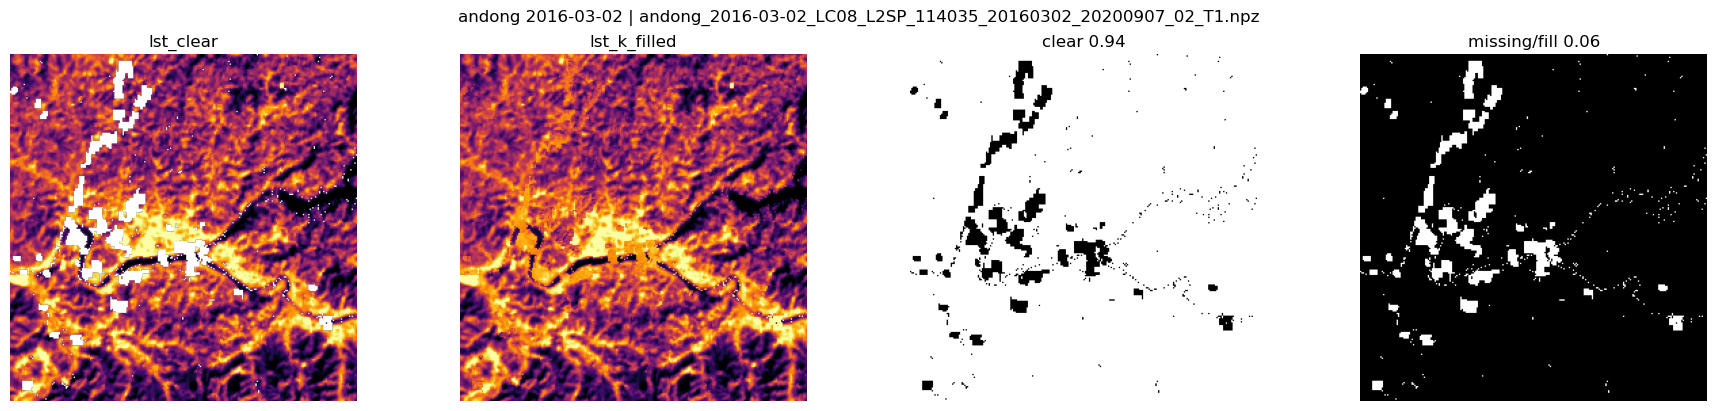

In [36]:

paths = dnn_sample_paths if "dnn_sample_paths" in globals() and dnn_sample_paths else sorted(SAMPLE_DIR.glob("*/*.npz"))
if not paths:
    print("no samples yet")
else:
    path = paths[0]
    with np.load(path, allow_pickle=True) as z:
        target = z["target"].astype(np.float32)
        clear = as_2d_mask(z["clear_mask"])
        cloud = as_2d_mask(z["cloud_fill_mask"])
        city = scalar_str(z["city"])
        date = scalar_str(z["date"])
    raw = clean_lst_values(target[0])
    filled = clean_lst_values(target[1]) if target.shape[0] > 1 else np.full_like(raw, np.nan)
    vals = np.concatenate([raw[np.isfinite(raw)], filled[np.isfinite(filled)]]) if (np.isfinite(raw).any() or np.isfinite(filled).any()) else np.array([250, 320])
    vmin, vmax = np.nanpercentile(vals, [2, 98])
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)
    axes[0].imshow(raw, cmap="inferno", vmin=vmin, vmax=vmax); axes[0].set_title("lst_clear")
    axes[1].imshow(filled, cmap="inferno", vmin=vmin, vmax=vmax); axes[1].set_title("lst_k_filled")
    axes[2].imshow(clear, cmap="gray", vmin=0, vmax=1); axes[2].set_title(f"clear {clear.mean():.2f}")
    axes[3].imshow(cloud, cmap="gray", vmin=0, vmax=1); axes[3].set_title(f"missing/fill {cloud.mean():.2f}")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{city} {date} | {path.name}")
    plt.show()
